## A signal in the natural basis vs. the samplet basis

The same signal, written in two different orthonormal bases:

* the **natural basis** &mdash; the coefficients *are* the samples $f(x_i)$,
* the **samplet basis** &mdash; the coefficients are $\langle f, \sigma_j\rangle$.

Both bases are orthonormal, so both representations carry the same energy. The difference is
*how that energy is distributed*: in the samplet basis it collapses onto a handful of
coefficients, and those coefficients sit exactly where the signal is rough.

In [9]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## The signal

A smooth background, a steep kink at $x = 0.35$ and a narrow bump at $x = 0.7$.

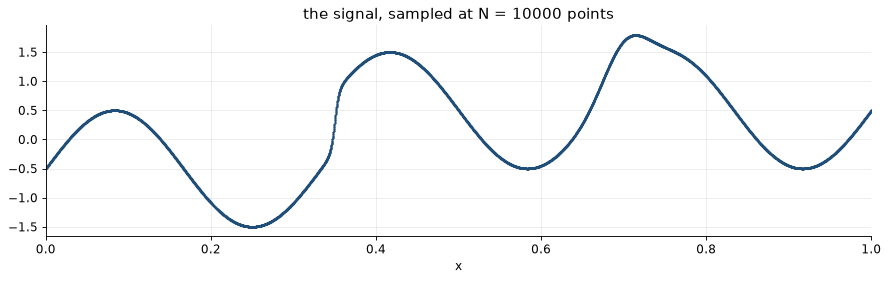

In [33]:
N, dtilde = 10000, 4

def signal(t):
    return (np.sin(6 * np.pi * t)
            + 0.5 * np.tanh(200 * (t - 0.35))
            + 0.6 * np.exp(-800 * (t - 0.7) ** 2))

pts = np.array(np.linspace(0, 1, N).reshape(1, N), order="F")
ST = FMCA.SampletTree(pts, dtilde)
x = pts[0, ST.indices()]                       # points in cluster order
f = np.asfortranarray(signal(x).reshape(-1, 1))  # data in cluster order

plt.figure(figsize=(11, 3.4))
plt.plot(x, f, ".", ms=1.4, color=C_DATA)
plt.title(f"the signal, sampled at N = {N} points")
plt.xlabel("x")
plt.xlim(0, 1)
plt.show()

## The two sets of coefficients

`sampletTransform` expects the data in **cluster order**, i.e. `data[ST.indices()]`, and returns
the samplet coefficients. The transform is orthogonal, so it is exactly invertible.

In [21]:
t0 = time.time()
c = ST.sampletTransform(f)
t1 = time.time()
back = ST.inverseSampletTransform(c)
t2 = time.time()

print(f"forward transform:   {t1 - t0:.4f} s")
print(f"backward transform:  {t2 - t1:.4f} s")
print(f"round trip error:    {np.linalg.norm(back - f) / np.linalg.norm(f):.2e}")
print(f"energy natural:      {np.linalg.norm(f):.6f}")
print(f"energy samplet:      {np.linalg.norm(c):.6f}   (orthogonal basis)")

forward transform:   0.0010 s
backward transform:  0.0006 s
round trip error:    9.64e-16
energy natural:      91.377677
energy samplet:      91.377677   (orthogonal basis)


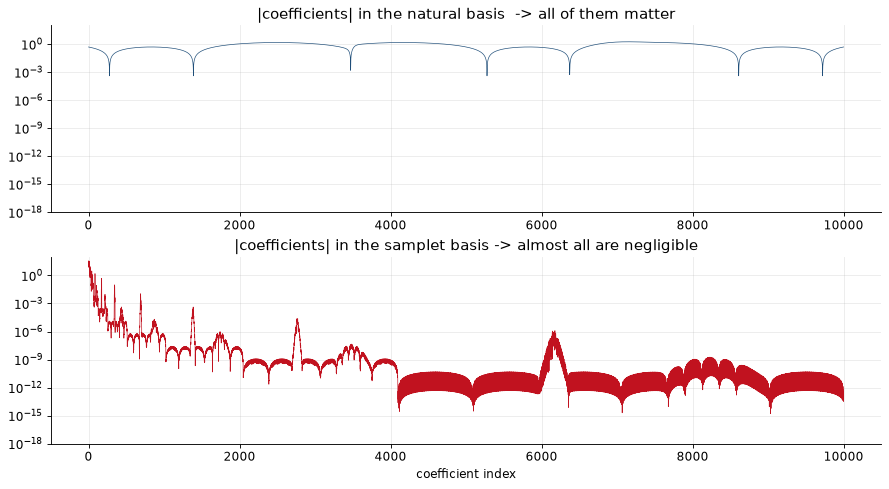

coefficients above 3.7e-05:  natural 10000   samplet   330   of 10000


In [25]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(np.abs(f), lw=0.6, color=C_DATA)
ax[0].set_yscale("log")
ax[0].set_ylim(1e-18, 1e2)
ax[0].set_title("|coefficients| in the natural basis  -> all of them matter")
ax[1].plot(np.abs(c), lw=0.6, color=C_SAMP)
ax[1].set_yscale("log")
ax[1].set_ylim(1e-18, 1e2)
ax[1].set_title("|coefficients| in the samplet basis -> almost all are negligible")
ax[1].set_xlabel("coefficient index")
plt.show()

tol = 1e-6 * np.abs(c).max()
print(f"coefficients above {tol:.1e}:  natural {int((np.abs(f) > tol).sum()):5d}"
      f"   samplet {int((np.abs(c) > tol).sum()):5d}   of {N}")

## Best $k$-term approximation

Keep only the $k$ largest coefficients, set the rest to zero and transform back. Because the
basis is orthonormal, this is the *best* $k$-term approximation in that basis, and the error is
simply the norm of the discarded coefficients.

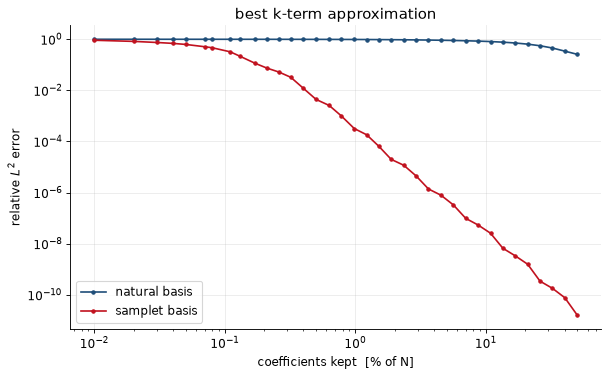

keep  0.5 % (  50 coeffs):  samplet 4.42e-03   natural 9.90e-01
keep  1.0 % ( 100 coeffs):  samplet 3.05e-04   natural 9.81e-01
keep  2.0 % ( 200 coeffs):  samplet 1.73e-05   natural 9.61e-01
keep  5.0 % ( 500 coeffs):  samplet 5.85e-07   natural 9.07e-01


In [27]:
def best_k_term(coeffs, k):
    """zero out all but the k largest entries (in modulus)"""
    out = np.zeros_like(coeffs)
    idx = np.argpartition(np.abs(coeffs.ravel()), -k)[-k:]
    out.ravel()[idx] = coeffs.ravel()[idx]
    return np.asfortranarray(out)

ks = np.unique(np.logspace(0, np.log10(N / 2), 40).astype(int))
err_s, err_n = [], []
for k in ks:
    rec = ST.inverseSampletTransform(best_k_term(c, k))
    err_s.append(np.linalg.norm(rec - f) / np.linalg.norm(f))
    err_n.append(np.linalg.norm(best_k_term(f, k) - f) / np.linalg.norm(f))

plt.figure(figsize=(7.5, 4.6))
plt.loglog(ks / N * 100, err_n, "o-", ms=3, color=C_DATA, label="natural basis")
plt.loglog(ks / N * 100, err_s, "o-", ms=3, color=C_SAMP, label="samplet basis")
plt.xlabel("coefficients kept  [% of N]")
plt.ylabel("relative $L^2$ error")
plt.title("best k-term approximation")
plt.legend()
plt.show()

for pct in (0.5, 1, 2, 5):
    k = int(pct / 100 * N)
    rec = ST.inverseSampletTransform(best_k_term(c, k))
    e_s = np.linalg.norm(rec - f) / np.linalg.norm(f)
    e_n = np.linalg.norm(best_k_term(f, k) - f) / np.linalg.norm(f)
    print(f"keep {pct:4.1f} % ({k:4d} coeffs):  samplet {e_s:.2e}   natural {e_n:.2e}")

## Reconstruction

With **1 %** of the coefficients the reconstruction is visually indistinguishable from the
original; the pointwise error is concentrated at the kink and the bump.

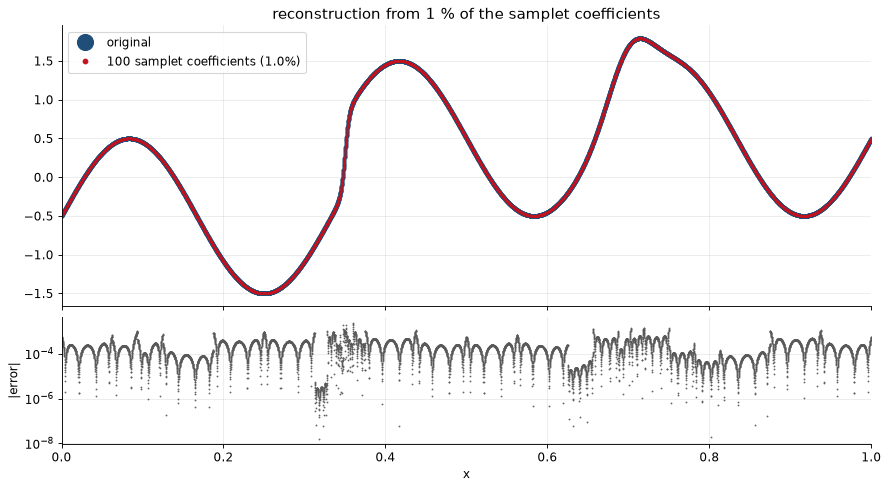

In [31]:
k = int(0.01 * N)
rec = ST.inverseSampletTransform(best_k_term(c, k)).ravel()

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       height_ratios=[2.2, 1])
ax[0].plot(x, f, ".", ms=4.8, color=C_DATA, label="original")
ax[0].plot(x, rec, ".", ms=1.4, color=C_SAMP, label=f"{k} samplet coefficients ({k/N:.1%})")
ax[0].legend(markerscale=6)
ax[0].set_title("reconstruction from 1 % of the samplet coefficients")
ax[1].semilogy(x, np.abs(rec - f.ravel()) + 1e-18, ".", ms=1.2, color="0.35")
ax[1].set_ylabel("|error|")
ax[1].set_xlabel("x")
ax[1].set_xlim(0, 1)
plt.show()